<a href="https://colab.research.google.com/github/ramiltrinidad-ctrl/maida/blob/main/FinalExam_01v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pycodestyle-magic pycodestyle flake8
%load_ext pycodestyle_magic
%pycodestyle_on

In [6]:
import numpy as np
from numpy.typing import NDArray
from PIL import Image
import matplotlib.pyplot as plt

# Instructions

1. There are 5 questions on Numpy, each 10 points.
1. For each question, you must write the function to conform to the dosctring and type-hinting.  
A copy of the summarizing doctring is left in the markdown cells above the function.
1. There are certain restrictions:
    1. You must vectorize your code, and for-loops (either explicit loops or list comprehension) for these particular problems should almost never be used.
    1. The functions are also restricted in the number of lines of working code that may be included.  
    New lines for formatting and hanging indents don't count towards this, but return and print statements do.  
    Semi-colons for putting multiple commands on the same line are explicitly forbidden.
    1. You may only use the Python Standard Library and whatever is imported above.
1. Do not change the function names or argument definitions.

## Rubric

1. Code has no runtime errors with valid attempt to solve problem - **[2 pts.]**
1. Code is mostly vectorized, and has no unneccessary for-loops - **[2 pts.]**
1. Code is within line limits with valid attempt to solve problem - **[2 pts.]**
1. Code solves the problem as specified by dosctring - **[4 pts.]**

# Problem 1 [10 pts.]

Calculate the Hadamard product, $\textbf{H}$, of $2$ input matrices $\textbf{A}$ and $\textbf{B}$ whose entries are defined by
$$\text{H}_{ij} = \text{A}_{ij} * \text{B}_{ij}$$
where $i$ is the row number, $j$ is the column number, and $*$ denotes typical (arithmetic) multiplication.  
No need to put guardrails for datatypes, just assume the inputs are the right type.

May NOT exceed 1 line of working code (numpy one-liner).  
Empty lines and formatting (e.g. for hanging indents) are excluded.

In [9]:
def hadamard(
    mat_A: NDArray[np.number],
    mat_B: NDArray[np.number],
) -> NDArray[np.number]:
    """
    Calculates the Hadamard product H of 2 matrices, A and B, whose
    entries are defined as

        H_{ij} = A_{ij}*B_{ij}

    where i is the row number, $j$ is the column number, and $*$ denotes
    typical (arithmetic) multiplication. No need to put guardrails for
    datatypes, just assume the inputs are the right type.

    May NOT exceed 1 line of working code (numpy one-liner).
    Empty lines and formatting (e.g. for hanging indents) are excluded.

    Parameters
    ----------
    mat_A : NDArray[np.number]
        Matrix A of some shape (same as B) containing numbers

    mat_B : NDArray[np.number]
        Matrix B of some shape (same as A) containing numbers

    Returns
    -------
    NDArray[np.number]
        Hadamard product of same shape and element type as the input
        matrices.

    Notes
    -----
    In the case the input element types are dissimilar, the output
    should go to the higher-bit accuracy.
    """
    return mat_A * mat_B

# Problem 2 [10 pts.]

Calculate the angle (in radians) between $2$ vectors, $\vec{v_1}$ and $\vec{v_2}$ to $64$-bit precision.  
Note that these vectors have the same dimension, but the dimensionality can be arbitrarily high.  
You may assume the input vectors are the correct type and compatible, no need for guardrails.

You may NOT exceed 1 line of working code (numpy one-liner).  
Empty lines and formatting (e.g. for hanging indents) are excluded

*Hint:* Recall the dot-product.

In [12]:
def vec_angle(
    v1: NDArray[np.number],
    v2: NDArray[np.number]
) -> np.float64:
    """
    Calculate the angle (in radians) between $2$ vectors, v_1 and v_2 to
    64-bit precision. Note that these vectors have the same dimension,
    but the dimensionality can be arbitrarily high. You may assume the
    input vectors are the correct type and compatible, no need for
    guardrails.

    May NOT exceed 1 line of working code (numpy one-liner).
    Empty lines and formatting (e.g. for hanging indents) are excluded.

    Parameters
    ----------
    v1 : NDArray[np.number]
        A vector of some dimensionality (read: shape (N,) or (,N))
        containing numbers

    v2 : NDArray[np.number]
        A vector of some dimensionality (read: shape (N,) or (,N))
        containing numbers, whose shape matches v1

    Returns
    -------
    np.float64
        Angle in radians between the vectors

    Notes
    -----
    The vectors can be either row or column-vectors.
    BEWARE floating point errors.
    """
    return np.arccos(
        np.clip(
            np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)),
            -1.0,
            1.0
        )
    )

# Problem 3 [10 pts.]

Calculate the value of a particular function, $r(p)$, defined as
$$r(p) = \frac{\Gamma(1 + 1/p)^2}{\Gamma(1 + 2/p)}$$
INDEPENDENTLY by Monte Carlo method (not analytically).

**Plan:**  
Generate $N$ points, each with coordinates of $(x, y)$, within in a $1\times1$ box (bottom-left corner at the origin).  
Then calculate all $L_p$ distances to the origin, where the $L_p$ distance to origin is
$$L_p(x_i, y_i) = (|x_i|^p + |y_i|^p)^{1/p}$$
The answer is the ratio of all points within $L_p \leq 1$ over N to $64$-bit precision.

You may NOT exceed 2 lines of working code.  
Empty lines and formatting (e.g. for hanging indents) are excluded.

In [16]:
def ratio_MC(
    N: int | np.integer = 10**8,
    p: int | float | np.number = 2
) -> np.float64:
    """
    Calculates the value of a particular function, r(p), defined as

        r(p) = Gamma(1 + 1/p)^2 / Gamma(1 + 2/p)

    INDEPENDENTLY by Monte Carlo method (not analytically).

    Plan:
    Generate N points, each with coordinates of (x, y), within in a
    1 x 1 box (bottom-left corner at the origin). Then calculate all
    Lp distances to the origin, where the Lp distance to origin is

        L_p(x_i, y_i) = (|x_i|^p + |y_i|^p)^(1/p)

    The answer is the ratio of all points within Lp <= 1 over N to 64-bit
    precision.

    May NOT exceed 2 lines of working code.
    Empty lines and formatting (e.g. for hanging indents) are excluded.

    Parameters
    ----------
    N : int | np.integer
        Number of points to generate

    p : int | float | np.number
        p-value for Gamma function, and parameter for Lp-norm
        Must be greater than 0

    Returns
    -------
    np.float64
        Approximated ratio
    """
    # Generate N points within a 1x1 box
    points = np.random.rand(N, 2)
    # Calculate Lp distances and ratio of points within Lp <= 1
    return (
        np.sum(
            (np.abs(points[:, 0])**p + np.abs(points[:, 1])**p)**(1/p) <= 1
        ) / N
    )

# Problem 4 [10 pts.]

Compute the n$^{\text{th}}$ Fibonacci number, $F_{n}$, defined by
$$F_{n} = F_{n-1} + F_{n-2}$$
SPECIFICALLY using matrix exponentiation.  
This method uses the generalization of:
$$
\begin{bmatrix}
1 & 1 \\
1 & 0
\end{bmatrix} =
\begin{bmatrix}
F_{2} & F_{1} \\
F_{1} & F_{0}
\end{bmatrix}
$$
You may NOT exceed 2 lines of working code.  
Empty lines and formatting (e.g. for hanging indents) are excluded.

In [20]:
def fib_mat(
    n: int | np.integer
) -> np.int64:
    """
    Compute the n-th Fibonacci number, F_{n}, SPECIFCIALLY using matrix
    exponentiation. This method uses the generalization of:

        [[1, 1], [1, 0]] = [[F_{2}, F_{1}], [F_{1}, F_{0}]]

    May NOT exceed 3 lines of working code. Empty lines and formatting
    (e.g. for hanging indents) are excluded.

    Parameters
    ----------
    n : int or numpy.integer
        Index of the Fibonacci number to compute.
        Assume n >= 2, don't bother putting guardrails.

    Returns
    -------
    np.int64
        The n-th Fibonacci number, computed to 64-bit precision.

    Notes
    -----
    This is effectively the same as a dynamic programming approach,
    just slightly more mathematically convenient.
    """
    fib_matrix = np.array([[1, 1], [1, 0]], dtype=np.int64)
    return np.linalg.matrix_power(fib_matrix, n - 1)[0, 0]

# Problem 5 [10 pts.]

Implement the discrete version of [Arnold's cat map](https://en.wikipedia.org/wiki/Arnold%27s_cat_map),
$\Gamma\left(\begin{bmatrix}
x \\
y
\end{bmatrix}\right)$
$$
\Gamma\left(\begin{bmatrix}
x \\
y
\end{bmatrix}\right) =
\begin{bmatrix}
2 & 1 \\
1 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix} \mod 1
$$
as a function that transforms an image chaotically, but with periodicity.

You may use up to 15 lines of working code.  
Empty lines and formatting (e.g. for hanging indents) are excluded.

In [52]:
def cat_map(
    img: NDArray[np.integer],
    iters: int | np.integer = 0
) -> NDArray[np.integer]:
    """
    Implement the discrete version of [Arnold's cat map], Gamma ([x, y])

        Gamma([x, y]) = [[2, 1], [1, 1]][x, y]

    as a function that transforms an image chaotically, with periodicity.

    You may use up to 15 lines of working code.
    Empty lines and formatting (e.g. for hanging indents) are excluded.

    Parameters
    ----------
    img : NDArray[np.integer]
        Square matrix to transform. Only needs to be square in the
        first 2 dimensions, can have arbitrary dimensions otherwise. To
        open images specifically, you will need something like Image.open()
        from PIL.

    iters : int or np.integer
        Number of times to apply the transformation to the coordinates.

    Returns
    -------
    NDArray[np.integer]
        The transformed image

    See Also
    --------
    ./cat.png : Provided test image

    Notes
    -----
    For a given image size, there are periodic values of iter which will
    return the original image.
    """
    M = img.shape[0]
    x_orig, y_orig = np.indices((M, M))

    coords = np.stack((x_orig.flatten(), y_orig.flatten()), axis=0)
    transformation_matrix = np.array([[2, 1], [1, 1]])
    current_coords = coords.copy()

    for _ in range(iters):
        current_coords = transformation_matrix @ current_coords % M

    x_new, y_new = current_coords.reshape(2, M, M)

    transformed_img = np.zeros_like(img)
    if img.ndim == 3:
        transformed_img[x_new, y_new, :] = img[x_orig, y_orig, :]
    else:
        transformed_img[x_new, y_new] = img[x_orig, y_orig]

    return transformed_img

In [47]:
from google.colab import drive
drive.mount('/content/drive')

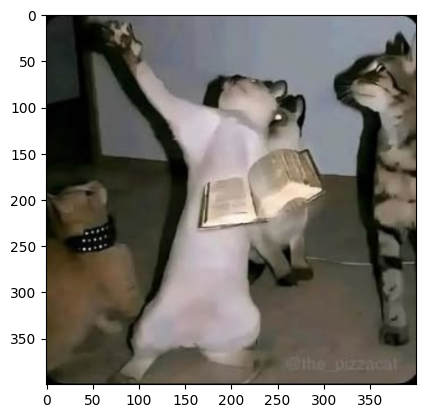

In [53]:
# Demo of image opening
image_path = '/content/drive/MyDrive/Final_01/Final_01/imgs/cat_000.png'
img = np.array(Image.open(image_path))
plt.imshow(img)
plt.show()

# End Of Section